# Retrieval Evaluation

This notebook produces  tables and figures for the retrieval evaluation
It covers the full ablation across retrieval families (BM25, Dense, RRF, SPLADE) with and without cross-encoder reranking, evaluated on the gold Standard and MTEB MuPLeR.

Embedding models compared: **BGE-M3** and **E5-Large-v2** and  **SPLADE** 
Reranker: `cross-encoder/ms-marco-MiniLM-L-6-v2` applied to top-5 candidates.  
Metrics: Hit Rate, MRR, NDCG at k ∈ {1, 3, 5, 10, 20}.

## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})
sns.set_style('whitegrid')


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'config.py').exists() and (path / 'README.md').exists():
            return path
    for path in [start, *start.parents]:
        if (path / 'config.py').exists():
            return path
    raise FileNotFoundError(
        f'Could not locate the repository root from {start}. Expected to find config.py.'
    )


# Paths
ROOT = find_repo_root()
OUT  = ROOT / 'outputs' / 'eval_mteb_k_split'

FIG_DIR = ROOT / 'outputs' / 'eval_mteb_k_split' / 'figures_thesis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT / 'metrics_all.csv'
assert metrics_path.exists(), f'metrics_all.csv not found in {OUT}\nAvailable files: {sorted(p.name for p in OUT.glob("*") ) if OUT.exists() else "<directory missing>"}'

# Load data
metrics = pd.read_csv(metrics_path)

# Include models
FOCUS_MODELS = ['bge-m3', 'e5-large-v2', 'splade']
metrics = metrics[metrics['model_key'].isin(FOCUS_MODELS)].copy()

print('Rows:', len(metrics))
print('Models:', sorted(metrics['model_key'].unique()))
print('Methods:', sorted(metrics['method'].unique()))
print('Datasets:', sorted(metrics['dataset'].unique()))
print('k values:', sorted(metrics['k'].unique()))

Rows: 140
Models: ['bge-m3', 'e5-large-v2', 'splade']
Methods: ['bm25', 'bm25_rerank', 'dense', 'dense_rerank', 'rrf', 'rrf_rerank', 'splade', 'splade_rerank']
Datasets: ['gold_standard', 'mteb_legal']
k values: [np.int64(1), np.int64(3), np.int64(5), np.int64(10), np.int64(20)]


In [3]:
# Display labels
METHOD_LABELS = {
    'bm25':          'BM25',
    'dense':         'Dense',
    'rrf':           'RRF',
    'bm25_rerank':   'BM25 + Rerank',
    'dense_rerank':  'Dense + Rerank',
    'rrf_rerank':    'RRF + Rerank',
    'splade':        'SPLADE',
    'splade_rerank': 'SPLADE + Rerank',
}
MODEL_LABELS = {
    'bge-m3':      'BGE-M3',
    'e5-large-v2': 'E5-Large-v2',
    'splade':      'SPLADE',
}
METHOD_ORDER = list(METHOD_LABELS.keys())

# Colors per model
MODEL_COLORS = {
    'bge-m3':      '#1f77b4',   # blue
    'e5-large-v2': '#d62728',   # red
    'splade':      '#2ca02c',   # green
}
MODEL_MARKERS = {'bge-m3': 'o', 'e5-large-v2': 's', 'splade': '^'}

def label_method(s):
    return METHOD_LABELS.get(s, s)

def label_model(s):
    return MODEL_LABELS.get(s, s)

def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved → {path.name}')


## 2. Gold Standard Ablation Table

Table 1 reports retrieval performance on the gold standard at k = 10. 
Metrics reported:
- **Hit Rate@10**: the fraction of queries for which the relevant document appears in the top-10 results (recall-oriented)
- **MRR@10**:  Mean Reciprocal Rank, which rewards higher-ranked correct answers
- **NDCG@10**: Normalised Discounted Cumulative Gain, which accounts for both rank position and relevance
Methods are grouped into three families: sparse (BM25, SPLADE), dense, and hybrid (RRF), each optionally followed by cross-encoder reranking.

In [4]:
gold_k10 = (
    metrics[
        (metrics['dataset'] == 'gold_standard') &
        (metrics['level']   == 'document') &
        (metrics['k']       == 10)
    ]
    .copy()
)

# Build one row per (method, model_key) with the three metrics
ablation = gold_k10[['method', 'model_key', 'hit_rate', 'mrr', 'ndcg']].copy()
ablation['method_label'] = ablation['method'].map(label_method)
ablation['model_label']  = ablation['model_key'].map(label_model)

# Pivot to wide: rows = method, columns = (model, metric)
wide = ablation.pivot_table(
    index='method',
    columns='model_key',
    values=['hit_rate', 'mrr', 'ndcg'],
    aggfunc='mean',
)
# Flatten columns: (metric, model)
wide.columns = [f'{m}_{k}' for m, k in wide.columns]
wide = wide.reindex([m for m in METHOD_ORDER if m in wide.index])

# Build display table with multi-level columns
table_rows = []
for method, row in wide.iterrows():
    r = {'Method': label_method(method)}
    for model in ['bge-m3', 'e5-large-v2', 'splade']:
        for metric, col_suffix in [('Hit@10', 'hit_rate'), ('MRR@10', 'mrr'), ('NDCG@10', 'ndcg')]:
            col = f'{col_suffix}_{model}'
            r[f'{label_model(model)} {metric}'] = row.get(col, np.nan)
    table_rows.append(r)

display_table = pd.DataFrame(table_rows).set_index('Method')

# Display settings
def highlight_max_col(s):
    is_max = s == s.max(skipna=True)
    return ['font-weight: bold' if v else '' for v in is_max]

styled = (
    display_table
    .style
    .format('{:.3f}', na_rep='—')
    .apply(highlight_max_col, axis=0)
    .set_caption('Table 1 — Retrieval performance on Gold Standard (document level, k=10)')
)
display(styled)

,BGE-M3 Hit@10,BGE-M3 MRR@10,BGE-M3 NDCG@10,E5-Large-v2 Hit@10,E5-Large-v2 MRR@10,E5-Large-v2 NDCG@10,SPLADE Hit@10,SPLADE MRR@10,SPLADE NDCG@10
Method,,,,,,,,,
BM25,0.585,0.318,0.382,0.585,0.318,0.382,—,—,—
Dense,0.692,0.480,0.531,0.692,0.501,0.550,—,—,—
RRF,0.531,0.435,0.458,0.554,0.446,0.472,—,—,—
BM25 + Rerank,0.615,0.429,0.473,0.615,0.429,0.473,—,—,—
Dense + Rerank,0.738,0.486,0.546,0.692,0.478,0.530,—,—,—
RRF + Rerank,0.523,0.429,0.453,0.554,0.427,0.459,—,—,—
SPLADE,—,—,—,—,—,—,0.685,0.439,0.499
SPLADE + Rerank,—,—,—,—,—,—,0.723,0.518,0.567


In [5]:
# LaTeX table
latex_df = display_table.copy()
latex_df = latex_df.rename_axis('Method')

def fmt_bold(col):
    best = col.max(skipna=True)
    def _fmt(v):
        if pd.isna(v):
            return '—'
        s = f'{v:.3f}'
        return f'\\textbf{{{s}}}' if abs(v - best) < 1e-9 else s
    return col.map(_fmt)

latex_bold = latex_df.apply(fmt_bold, axis=0)
latex_str = latex_bold.to_latex(
    escape=False,
    column_format='l' + 'r' * len(latex_bold.columns),
    caption='Retrieval performance on the gold standard query set (document level, $k=10$).',
    label='tab:retrieval_ablation_k10',
)
print(latex_str)

\begin{table}
\caption{Retrieval performance on the gold standard query set (document level, $k=10$).}
\label{tab:retrieval_ablation_k10}
\begin{tabular}{lrrrrrrrrr}
\toprule
 & BGE-M3 Hit@10 & BGE-M3 MRR@10 & BGE-M3 NDCG@10 & E5-Large-v2 Hit@10 & E5-Large-v2 MRR@10 & E5-Large-v2 NDCG@10 & SPLADE Hit@10 & SPLADE MRR@10 & SPLADE NDCG@10 \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
BM25 & 0.585 & 0.318 & 0.382 & 0.585 & 0.318 & 0.382 & — & — & — \\
Dense & 0.692 & 0.480 & 0.531 & \textbf{0.692} & \textbf{0.501} & \textbf{0.550} & — & — & — \\
RRF & 0.531 & 0.435 & 0.458 & 0.554 & 0.446 & 0.472 & — & — & — \\
BM25 + Rerank & 0.615 & 0.429 & 0.473 & 0.615 & 0.429 & 0.473 & — & — & — \\
Dense + Rerank & \textbf{0.738} & \textbf{0.486} & \textbf{0.546} & \textbf{0.692} & 0.478 & 0.530 & — & — & — \\
RRF + Rerank & 0.523 & 0.429 & 0.453 & 0.554 & 0.427 & 0.459 & — & — & — \\
SPLADE & — & — & — & — & — & — & 0.685 & 0.439 & 0.499 \\
SPLADE + Rerank & — & — & — & — & — & — & \textbf{0.723} 


## 3. Metric Trends Across k

The following plots show how Hit Rate, MRR, and NDCG evolve as the retrieval cut-off k increases from 1 to 20.  
These curves illustrate the trade-off between recall (more documents retrieved) and precision (higher-ranked relevance).  
It compares models BGE-M3 and E5-Large-v2 across all retrieval methods.

Saved → fig_metric_trends_by_k.png


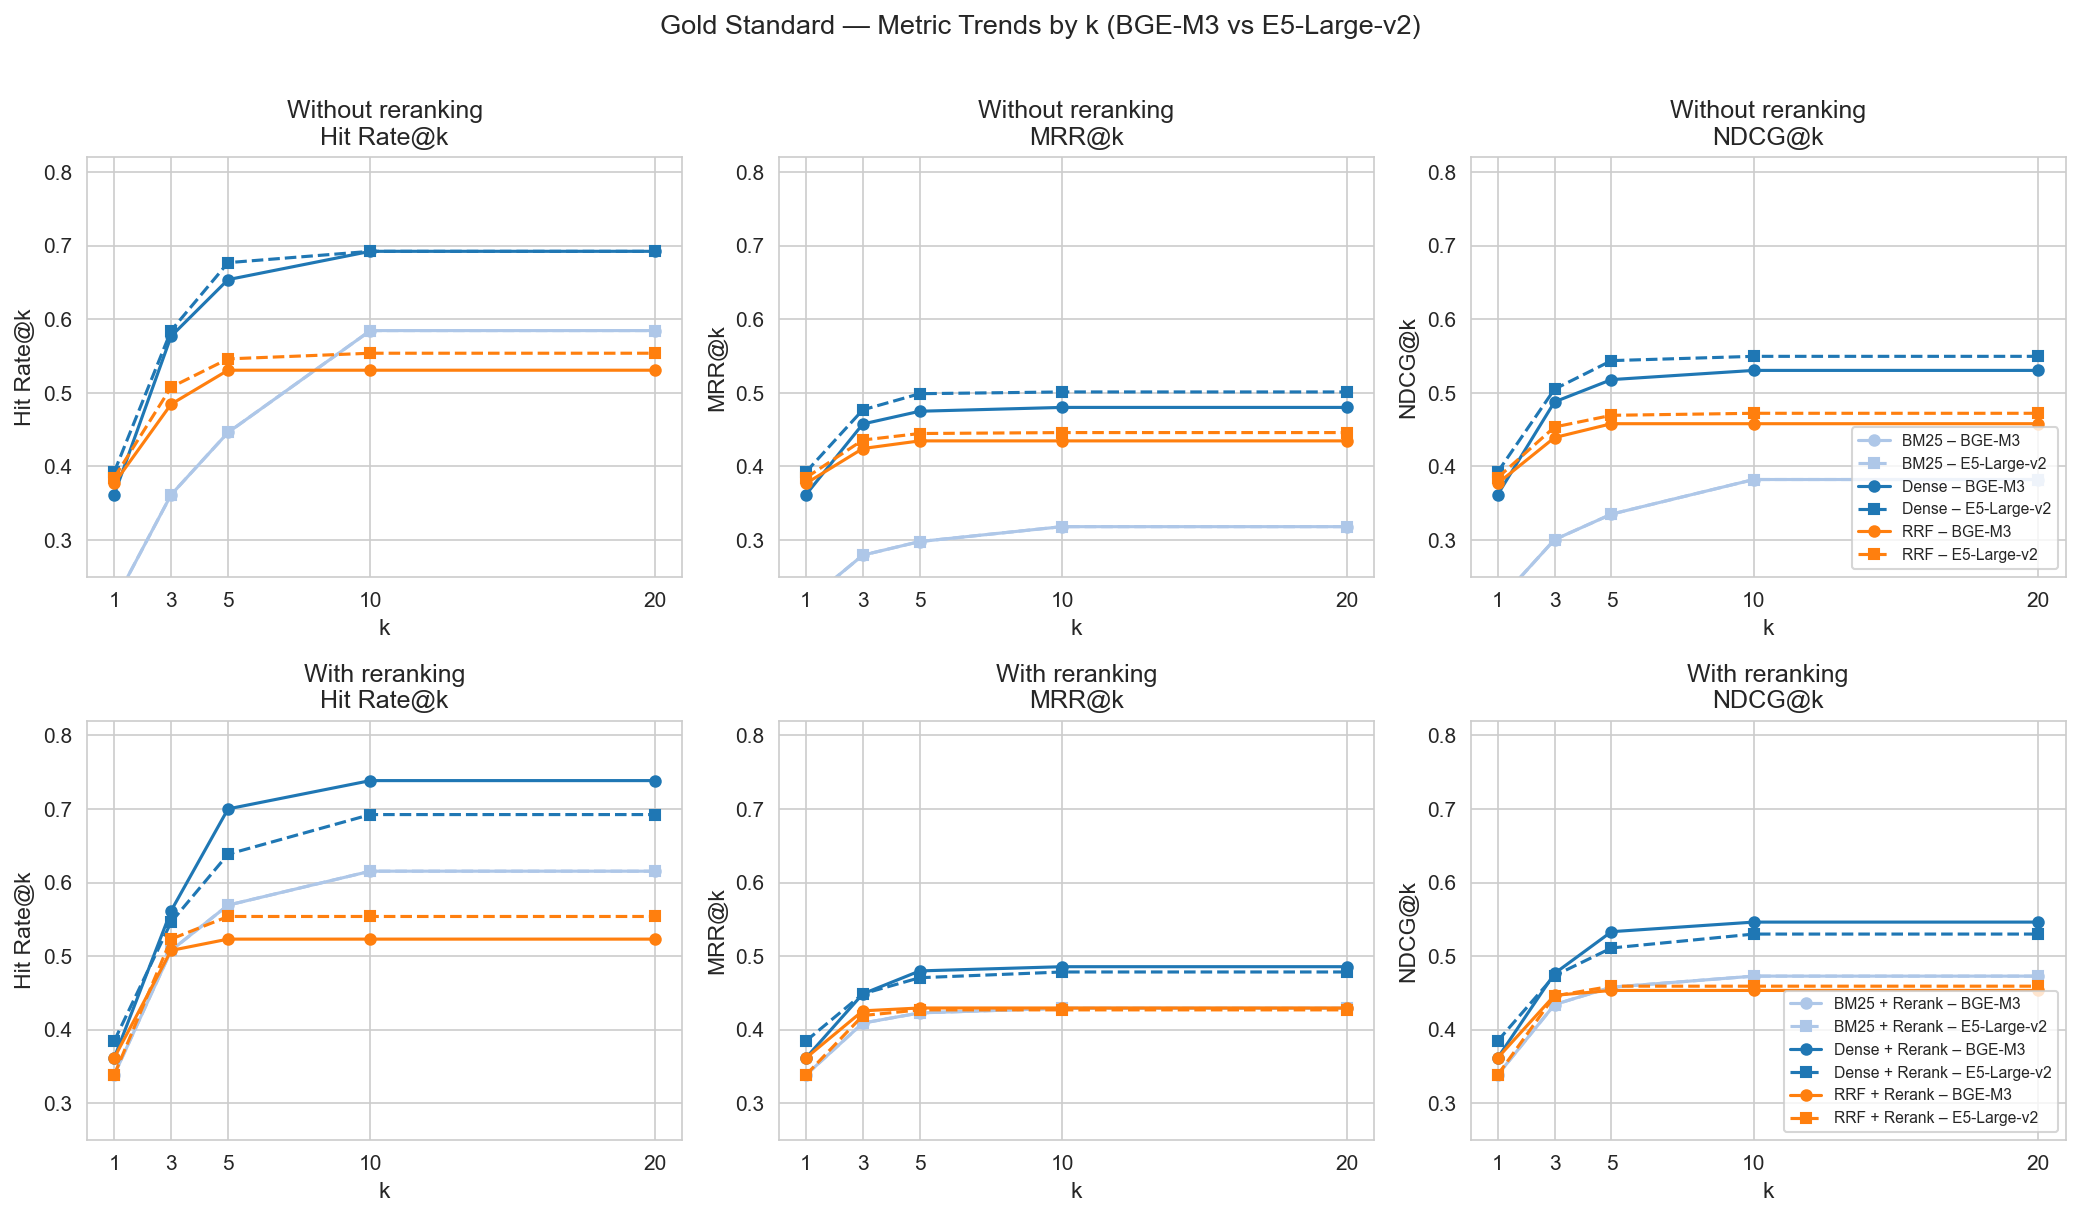

In [6]:
gold_all_k = metrics[
    (metrics['dataset'] == 'gold_standard') &
    (metrics['level']   == 'document') &
    (metrics['model_key'].isin(['bge-m3', 'e5-large-v2']))
].copy()

gold_all_k['method_label'] = gold_all_k['method'].map(label_method)

# Methods
SHOW_METHODS = ['bm25', 'dense', 'rrf', 'bm25_rerank', 'dense_rerank', 'rrf_rerank']
plot_df = gold_all_k[gold_all_k['method'].isin(SHOW_METHODS)].copy()

METRICS_PLOT = [('hit_rate', 'Hit Rate@k'), ('mrr', 'MRR@k'), ('ndcg', 'NDCG@k')]
K_VALS = [1, 3, 5, 10, 20]

linestyles = {'bge-m3': '-', 'e5-large-v2': '--'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)

row_groups = [
    ('Without reranking', ['bm25', 'dense', 'rrf']),
    ('With reranking',    ['bm25_rerank', 'dense_rerank', 'rrf_rerank']),
]

for row_idx, (row_title, methods) in enumerate(row_groups):
    for col_idx, (metric_col, metric_label) in enumerate(METRICS_PLOT):
        ax = axes[row_idx][col_idx]
        sub = plot_df[plot_df['method'].isin(methods)]

        method_colors = {
            'bm25':  '#aec7e8', 'bm25_rerank':  '#aec7e8',
            'dense': '#1f77b4', 'dense_rerank': '#1f77b4',
            'rrf':   '#ff7f0e', 'rrf_rerank':   '#ff7f0e',
        }

        for method in methods:
            for model in ['bge-m3', 'e5-large-v2']:
                mdf = sub[(sub['method'] == method) & (sub['model_key'] == model)]
                if mdf.empty:
                    continue
                mdf = mdf.sort_values('k')
                lbl = f'{METHOD_LABELS[method]} – {MODEL_LABELS[model]}'
                ax.plot(
                    mdf['k'], mdf[metric_col],
                    color=method_colors[method],
                    linestyle=linestyles[model],
                    marker=MODEL_MARKERS[model],
                    markersize=5,
                    label=lbl,
                )

        ax.set_xticks(K_VALS)
        ax.set_xlabel('k')
        ax.set_ylabel(metric_label)
        ax.set_title(f'{row_title}\n{metric_label}')
        ax.set_ylim(0.25, 0.82)
        if col_idx == 2:
            ax.legend(fontsize=7.5, loc='lower right')

plt.suptitle('Gold Standard — Metric Trends by k (BGE-M3 vs E5-Large-v2)', fontsize=13, y=1.01)
plt.tight_layout()
savefig('fig_metric_trends_by_k.png')
plt.show()


## 4. Reranking Effect: Delta Analysis

This section quantifies the absolute gain from applying cross-encoder reranking on top of each base retrieval method at k = 10.  
The delta is computed as `metric(reranked) − metric(base)` for each pair

,Base Method,Model,ΔHit@10,ΔMRR@10,ΔNDCG@10
0,BM25,BGE-M3,+0.031,+0.111,+0.091
1,BM25,E5-Large-v2,+0.031,+0.111,+0.091
2,Dense,BGE-M3,+0.046,+0.005,+0.016
3,Dense,E5-Large-v2,+0.000,-0.023,-0.020
4,RRF,BGE-M3,-0.008,-0.005,-0.005
5,RRF,E5-Large-v2,+0.000,-0.019,-0.013
6,SPLADE,SPLADE,+0.038,+0.079,+0.068


Saved → fig_reranking_delta.png


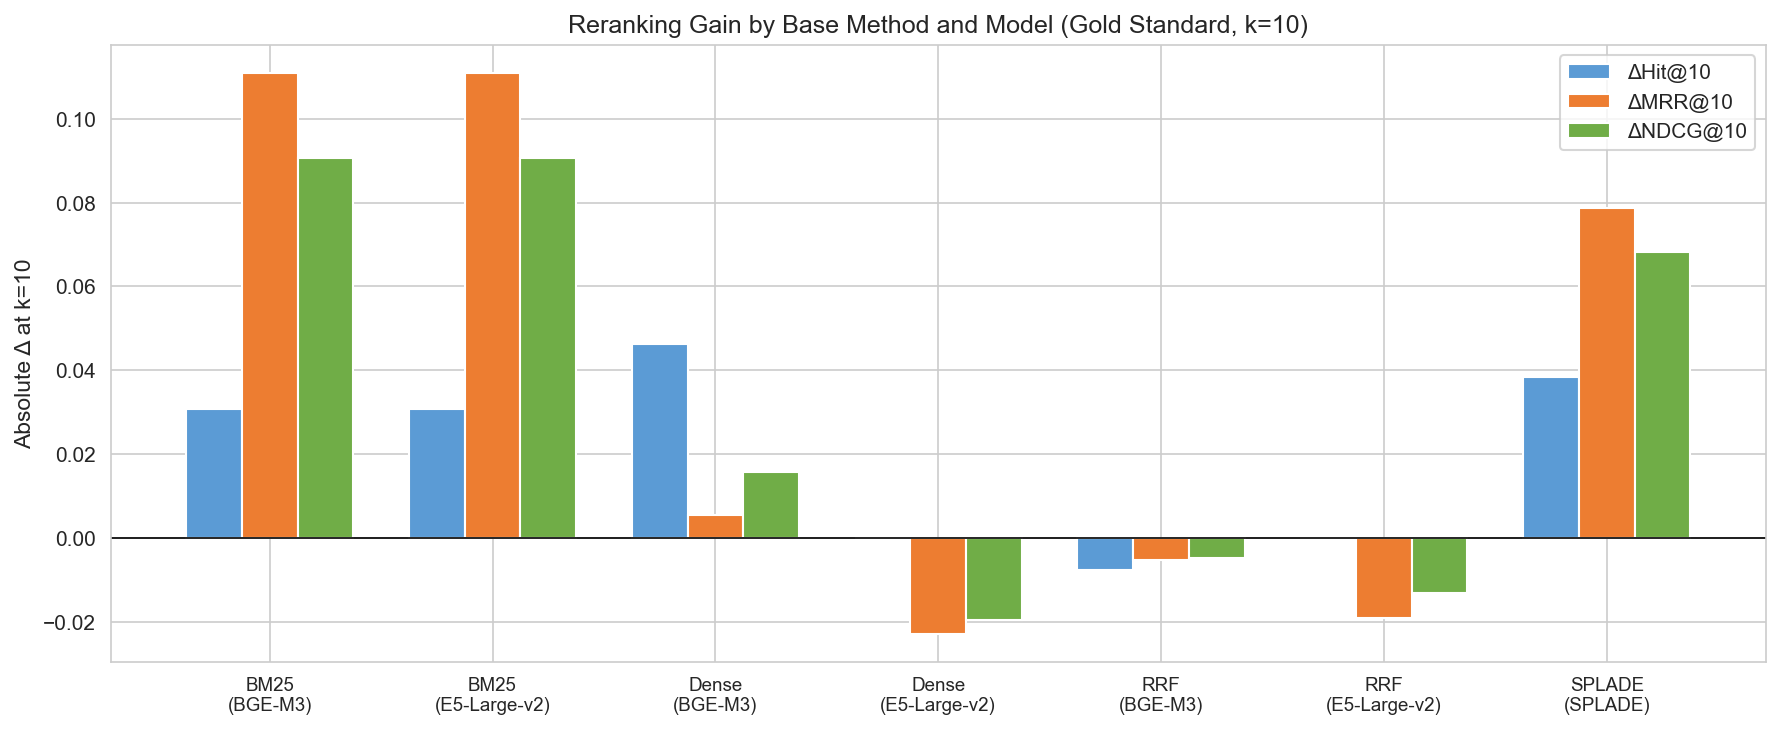

In [7]:
k10_gold = metrics[
    (metrics['dataset'] == 'gold_standard') &
    (metrics['level']   == 'document') &
    (metrics['k']       == 10)
].copy()

PAIRS = [('bm25', 'bm25_rerank'), ('dense', 'dense_rerank'), ('rrf', 'rrf_rerank')]

delta_rows = []
for base, reranked in PAIRS:
    for model in ['bge-m3', 'e5-large-v2']:
        b = k10_gold[(k10_gold['method'] == base) & (k10_gold['model_key'] == model)]
        r = k10_gold[(k10_gold['method'] == reranked) & (k10_gold['model_key'] == model)]
        if b.empty or r.empty:
            continue
        delta_rows.append({
            'Base Method': METHOD_LABELS[base],
            'Model':       MODEL_LABELS[model],
            'ΔHit@10':    float(r['hit_rate'].values[0] - b['hit_rate'].values[0]),
            'ΔMRR@10':    float(r['mrr'].values[0]      - b['mrr'].values[0]),
            'ΔNDCG@10':   float(r['ndcg'].values[0]     - b['ndcg'].values[0]),
        })

delta_df = pd.DataFrame(delta_rows)

# Add SPLADE row 
b_sp = k10_gold[(k10_gold['method'] == 'splade')        & (k10_gold['model_key'] == 'splade')]
r_sp = k10_gold[(k10_gold['method'] == 'splade_rerank') & (k10_gold['model_key'] == 'splade')]
if not b_sp.empty and not r_sp.empty:
    delta_rows.append({
        'Base Method': 'SPLADE',
        'Model':       'SPLADE',
        'ΔHit@10':    float(r_sp['hit_rate'].values[0] - b_sp['hit_rate'].values[0]),
        'ΔMRR@10':    float(r_sp['mrr'].values[0]      - b_sp['mrr'].values[0]),
        'ΔNDCG@10':   float(r_sp['ndcg'].values[0]     - b_sp['ndcg'].values[0]),
    })
    delta_df = pd.DataFrame(delta_rows)

# Display styled table
styled_delta = (
    delta_df.style
    .format({'ΔHit@10': '{:+.3f}', 'ΔMRR@10': '{:+.3f}', 'ΔNDCG@10': '{:+.3f}'})
    .background_gradient(subset=['ΔNDCG@10'], cmap='RdYlGn', vmin=-0.05, vmax=0.10)
    .set_caption('Table 2 — Absolute gain from reranking at k=10 (reranked − base). Positive = reranking helps.')
)
display(styled_delta)

# Bar chart
melt = delta_df.melt(
    id_vars=['Base Method', 'Model'],
    value_vars=['ΔHit@10', 'ΔMRR@10', 'ΔNDCG@10'],
    var_name='Metric', value_name='Delta',
)
melt['Config'] = melt['Base Method'] + '\n(' + melt['Model'] + ')'

fig, ax = plt.subplots(figsize=(12, 5))
configs = melt['Config'].unique()
x = np.arange(len(configs))
width = 0.25
metric_colors = {'ΔHit@10': '#5B9BD5', 'ΔMRR@10': '#ED7D31', 'ΔNDCG@10': '#70AD47'}

for i, metric in enumerate(['ΔHit@10', 'ΔMRR@10', 'ΔNDCG@10']):
    vals = [melt[(melt['Config'] == c) & (melt['Metric'] == metric)]['Delta'].values[0]
            if not melt[(melt['Config'] == c) & (melt['Metric'] == metric)].empty else 0
            for c in configs]
    ax.bar(x + (i - 1) * width, vals, width, label=metric, color=metric_colors[metric])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylabel('Absolute Δ at k=10')
ax.set_title('Reranking Gain by Base Method and Model (Gold Standard, k=10)')
ax.legend()
plt.tight_layout()
savefig('fig_reranking_delta.png')
plt.show()


## 5. Heatmap: NDCG@10 by Method and Model

The heatmap provides a compact visual comparison of NDCG@10 across all retrieval configurations for the gold standard dataset.

Saved → fig_heatmap_gold_k10.png


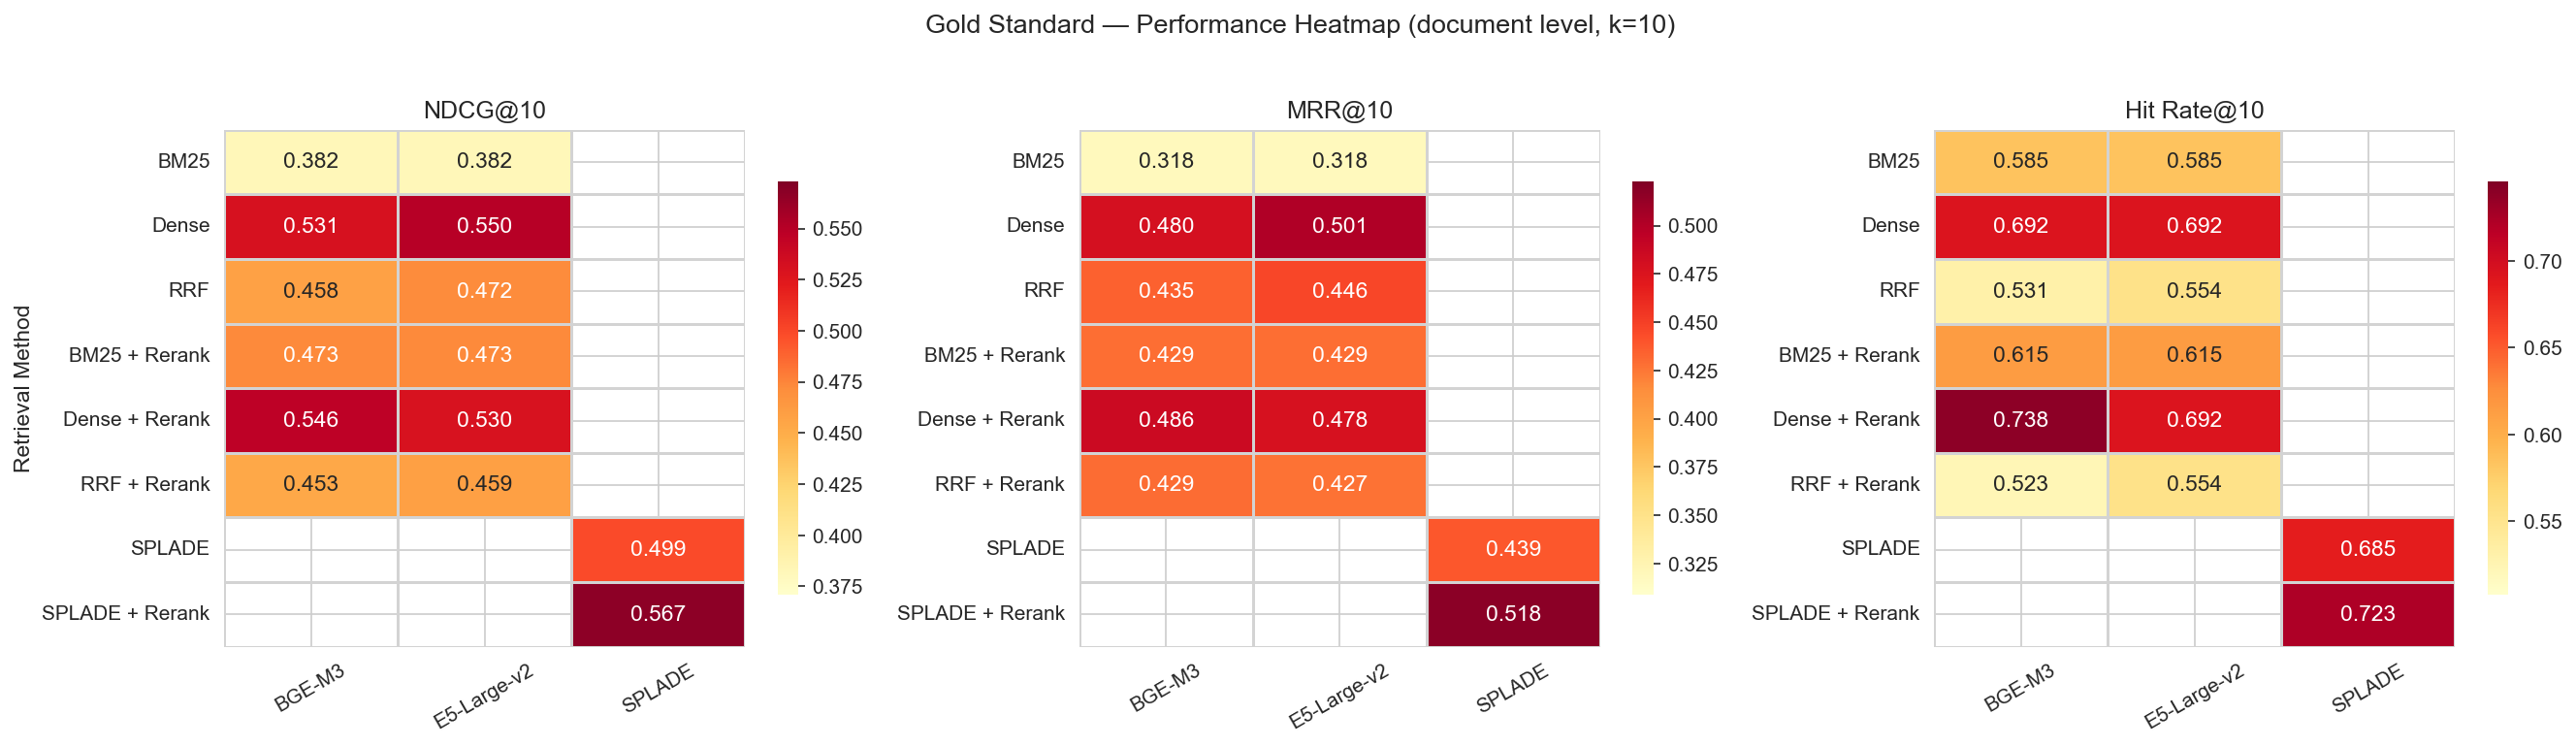

In [8]:
# Build pivot: rows = method, columns = model
hm_data = k10_gold[['method', 'model_key', 'ndcg', 'mrr', 'hit_rate']].copy()
hm_data['method_label'] = hm_data['method'].map(label_method)
hm_data['model_label']  = hm_data['model_key'].map(label_model)

method_order_labels = [label_method(m) for m in METHOD_ORDER if m in hm_data['method'].values]
model_order_labels  = ['BGE-M3', 'E5-Large-v2', 'SPLADE']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric_col, metric_title) in zip(axes, [('ndcg', 'NDCG@10'), ('mrr', 'MRR@10'), ('hit_rate', 'Hit Rate@10')]):
    pivot = hm_data.pivot_table(
        index='method_label', columns='model_label',
        values=metric_col, aggfunc='mean',
    ).reindex(index=method_order_labels, columns=model_order_labels)

    vmin = pivot.min().min() * 0.97
    vmax = pivot.max().max() * 1.01

    sns.heatmap(
        pivot,
        ax=ax, annot=True, fmt='.3f',
        cmap='YlOrRd', vmin=vmin, vmax=vmax,
        linewidths=0.5, linecolor='lightgrey',
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(metric_title, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Retrieval Method' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Gold Standard — Performance Heatmap (document level, k=10)', fontsize=13, y=1.02)
plt.tight_layout()
savefig('fig_heatmap_gold_k10.png')
plt.show()

## 6. Head-to-Head: BGE-M3 vs E5-Large-v2

This section directly compares the two primary embedding models across all methods and metrics at k = 10.  
A positive gap means BGE-M3 is better; negative means E5-Large-v2 is better.

,BGE-M3 NDCG,E5-Large-v2 NDCG,BGE-M3 MRR,E5-Large-v2 MRR,BGE-M3 Hit,E5-Large-v2 Hit,ΔNDCG (BGE−E5),ΔMRR (BGE−E5),ΔHit (BGE−E5)
Method,,,,,,,,,
Dense,0.531,0.550,0.480,0.501,0.692,0.692,-0.019,-0.021,0.000
RRF,0.458,0.472,0.435,0.446,0.531,0.554,-0.014,-0.011,-0.023
BM25 + Rerank,0.473,0.473,0.429,0.429,0.615,0.615,0.000,0.000,0.000
Dense + Rerank,0.546,0.530,0.486,0.478,0.738,0.692,0.016,0.007,0.046
RRF + Rerank,0.453,0.459,0.429,0.427,0.523,0.554,-0.006,0.003,-0.031


Saved → fig_h2h_gap.png


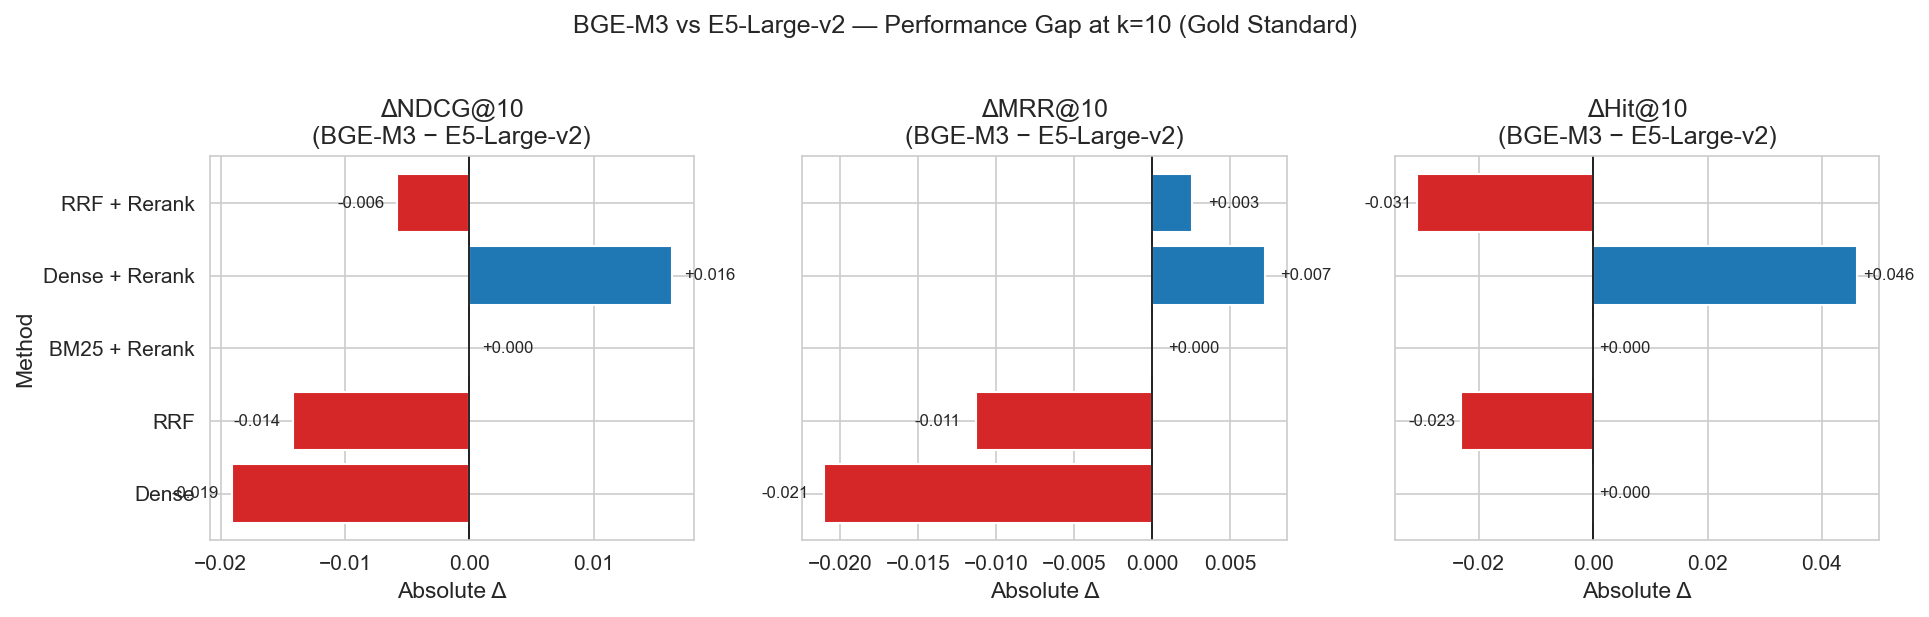

In [9]:
DENSE_METHODS = ['dense', 'rrf', 'bm25_rerank', 'dense_rerank', 'rrf_rerank']

h2h_rows = []
for method in DENSE_METHODS:
    bge = k10_gold[(k10_gold['method'] == method) & (k10_gold['model_key'] == 'bge-m3')]
    e5  = k10_gold[(k10_gold['method'] == method) & (k10_gold['model_key'] == 'e5-large-v2')]
    if bge.empty or e5.empty:
        continue
    row = {
        'Method':           METHOD_LABELS[method],
        'BGE-M3 NDCG':      bge['ndcg'].values[0],
        'E5-Large-v2 NDCG': e5['ndcg'].values[0],
        'BGE-M3 MRR':       bge['mrr'].values[0],
        'E5-Large-v2 MRR':  e5['mrr'].values[0],
        'BGE-M3 Hit':       bge['hit_rate'].values[0],
        'E5-Large-v2 Hit':  e5['hit_rate'].values[0],
        'ΔNDCG (BGE−E5)':   bge['ndcg'].values[0]     - e5['ndcg'].values[0],
        'ΔMRR (BGE−E5)':    bge['mrr'].values[0]      - e5['mrr'].values[0],
        'ΔHit (BGE−E5)':    bge['hit_rate'].values[0] - e5['hit_rate'].values[0],
    }
    h2h_rows.append(row)

h2h = pd.DataFrame(h2h_rows).set_index('Method')

styled_h2h = (
    h2h.style
    .format('{:.3f}', na_rep='—')
    .background_gradient(subset=['ΔNDCG (BGE−E5)', 'ΔMRR (BGE−E5)', 'ΔHit (BGE−E5)'],
                         cmap='RdBu', vmin=-0.03, vmax=0.03)
    .set_caption('Table 3 — Head-to-head comparison at k=10 (gold standard).')
)
display(styled_h2h)

# ── diverging bar chart: BGE-M3 vs E5-Large-v2 ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (metric, col) in zip(axes, [('NDCG@10', 'ΔNDCG (BGE−E5)'), ('MRR@10', 'ΔMRR (BGE−E5)'), ('Hit@10', 'ΔHit (BGE−E5)')]):
    colors = ['#1f77b4' if v >= 0 else '#d62728' for v in h2h[col]]
    ax.barh(h2h.index, h2h[col], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Δ{metric}\n(BGE-M3 − E5-Large-v2)')
    ax.set_xlabel('Absolute Δ')
    for i, v in enumerate(h2h[col]):
        ax.text(v + (0.001 if v >= 0 else -0.001), i, f'{v:+.3f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)

axes[0].set_ylabel('Method')
plt.suptitle('BGE-M3 vs E5-Large-v2 — Performance Gap at k=10 (Gold Standard)', fontsize=12, y=1.02)
plt.tight_layout()
savefig('fig_h2h_gap.png')
plt.show()

## 7. MTEB Benchmark: Legal Retrieval (MuPLeR)

Evaluation of all configurations on MuPLeR legal retrieval benchmark


\begin{table}
\caption{Chunk-level retrieval performance on the MTEB MuPLeR-retrieval benchmark at $k \in \{1, 5, 10\}$ (200 queries). Each model is reported under its best configuration (RRF + cross-encoder reranking for BGE-M3 and E5-Large-v2; SPLADE + Rerank for the sparse baseline). }
\label{tab:mteb}
\begin{tabular}{llrrrrrrrrr}
\toprule
 &  & Hit@1 & MRR@1 & NDCG@1 & Hit@5 & MRR@5 & NDCG@5 & Hit@10 & MRR@10 & NDCG@10 \\
Model & Method &  &  &  &  &  &  &  &  &  \\
\midrule
BGE-M3 & RRF + Rerank & \textbf{0.910} & \textbf{0.910} & \textbf{0.910} & \textbf{0.965} & \textbf{0.935} & \textbf{0.942} & \textbf{0.970} & \textbf{0.935} & \textbf{0.944} \\
\cline{1-11}
E5-Large-v2 & RRF + Rerank & \textbf{0.910} & \textbf{0.910} & \textbf{0.910} & \textbf{0.965} & 0.934 & 0.942 & \textbf{0.970} & 0.935 & 0.944 \\
\cline{1-11}
SPLADE & SPLADE + Rerank & 0.840 & 0.840 & 0.840 & 0.880 & 0.857 & 0.863 & 0.885 & 0.858 & 0.865 \\
\cline{1-11}
\bottomrule
\end{tabular}
\end{table}

Saved → fig_m

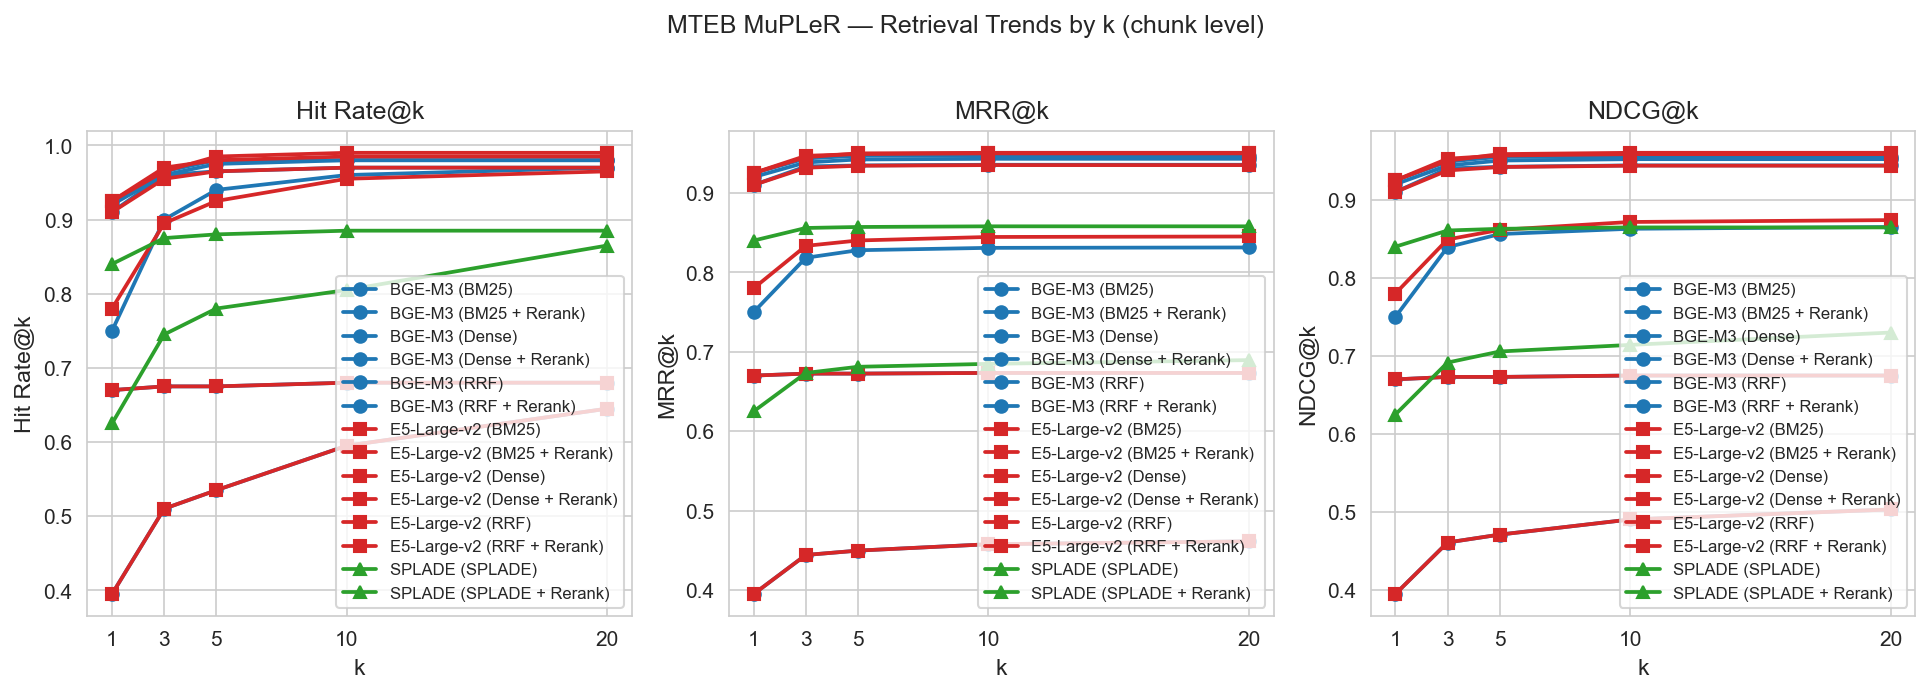

In [10]:
mteb_data = metrics[
    (metrics['dataset'] == 'mteb_legal') &
    (metrics['level']   == 'chunk')
].copy()

mteb_k_vals = sorted(mteb_data['k'].unique())

# Multi-k table (k=1, 5, 10)
MTEB_K_SHOW   = [1, 5, 10]
MTEB_MODELS   = ['bge-m3', 'e5-large-v2', 'splade']
MTEB_BEST_METHOD = {'bge-m3': 'rrf_rerank', 'e5-large-v2': 'rrf_rerank', 'splade': 'splade_rerank'}

table_rows = []
for model_key in MTEB_MODELS:
    method = MTEB_BEST_METHOD[model_key]
    row = {
        'Model':  MODEL_LABELS.get(model_key, model_key),
        'Method': METHOD_LABELS.get(method, method),
    }
    for k in MTEB_K_SHOW:
        sub = mteb_data[
            (mteb_data['model_key'] == model_key) &
            (mteb_data['method']    == method) &
            (mteb_data['k']         == k)
        ]
        if not sub.empty:
            row[f'Hit@{k}']  = sub['hit_rate'].values[0]
            row[f'MRR@{k}']  = sub['mrr'].values[0]
            row[f'NDCG@{k}'] = sub['ndcg'].values[0]
        else:
            row[f'Hit@{k}'] = row[f'MRR@{k}'] = row[f'NDCG@{k}'] = float('nan')
    table_rows.append(row)

mteb_multi_k = pd.DataFrame(table_rows).set_index(['Model', 'Method'])

# MultiIndex columns: (k=1, 5, 10) per metrics (Hit, MRR, NDCG)
col_tuples = [(f'$k={k}$', m) for k in MTEB_K_SHOW for m in ['Hit', 'MRR', 'NDCG']]
mteb_multi_k.columns = pd.MultiIndex.from_tuples(col_tuples)

styled_mteb = (
    mteb_multi_k.style
    .format('{:.3f}', na_rep='—')
    .highlight_max(axis=0, color='#d4edda')
    .set_caption(
        'Table 4 — MTEB MuPLeR performance (chunk level) at '
        r'k ∈ {1, 5, 10}. Best config per model.'
    )
)
display(styled_mteb)

# LaTeX export 
def fmt_bold_mteb(col):
    best = col.max(skipna=True)
    def _fmt(v):
        if pd.isna(v): return '—'
        s = f'{v:.3f}'
        return f'\\textbf{{{s}}}' if abs(v - best) < 1e-9 else s
    return col.map(_fmt)

latex_mteb = mteb_multi_k.copy()
latex_mteb.columns = [f'{m}@{k.split("=")[1].rstrip("$")}' for k, m in latex_mteb.columns]
latex_bold = latex_mteb.apply(fmt_bold_mteb, axis=0)
latex_str = latex_bold.to_latex(
    escape=False,
    multirow=True,
    column_format='ll' + 'r' * len(latex_bold.columns),
    caption=(
        r'Chunk-level retrieval performance on the MTEB MuPLeR-retrieval benchmark at $k \in \{1, 5, 10\}$ '
        r'(200 queries). Each model is reported under its best configuration '
        r'(RRF + cross-encoder reranking for BGE-M3 and E5-Large-v2; SPLADE + Rerank for the sparse baseline). '
    ),
    label='tab:mteb',
)
print(latex_str)

# Line charts by k
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, (metric_col, metric_label) in zip(axes, [('hit_rate', 'Hit Rate@k'), ('mrr', 'MRR@k'), ('ndcg', 'NDCG@k')]):
    for _, grp in mteb_data.groupby(['model_key', 'method']):
        grp = grp.sort_values('k')
        mk  = grp['model_key'].iloc[0]
        lbl = f"{MODEL_LABELS.get(mk, mk)} ({METHOD_LABELS.get(grp['method'].iloc[0], grp['method'].iloc[0])})"
        ax.plot(
            grp['k'], grp[metric_col],
            color=MODEL_COLORS.get(mk, 'grey'),
            marker=MODEL_MARKERS.get(mk, 'x'),
            markersize=6, linewidth=1.8,
            label=lbl,
        )
    ax.set_xticks(mteb_k_vals)
    ax.set_xlabel('k')
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label)
    ax.legend(fontsize=8)

plt.suptitle('MTEB MuPLeR — Retrieval Trends by k (chunk level)', fontsize=12, y=1.02)
plt.tight_layout()
savefig('fig_mteb_trends.png')
plt.show()

## 8. All-in-One Summary Table

The following table consolidates the key results from both datasets into a single publishable overview.

In [11]:
TARGET_K = 10

summary_rows = []

# Gold standard, all methods
gold_k10_all = metrics[
    (metrics['dataset'] == 'gold_standard') &
    (metrics['level']   == 'document') &
    (metrics['k']       == TARGET_K)
].copy()

for _, r in gold_k10_all.iterrows():
    summary_rows.append({
        'Dataset':   'Gold Standard',
        'Model':     MODEL_LABELS.get(r['model_key'], r['model_key']),
        'Method':    METHOD_LABELS.get(r['method'], r['method']),
        'Hit@10':    r['hit_rate'],
        'MRR@10':    r['mrr'],
        'NDCG@10':   r['ndcg'],
    })

# MTEB
mteb_k10_all = metrics[
    (metrics['dataset'] == 'mteb_legal') &
    (metrics['level']   == 'chunk') &
    (metrics['k']       == TARGET_K)
].copy()

for _, r in mteb_k10_all.iterrows():
    summary_rows.append({
        'Dataset':   'MTEB MuPLeR',
        'Model':     MODEL_LABELS.get(r['model_key'], r['model_key']),
        'Method':    METHOD_LABELS.get(r['method'], r['method']),
        'Hit@10':    r['hit_rate'],
        'MRR@10':    r['mrr'],
        'NDCG@10':   r['ndcg'],
    })

summary = pd.DataFrame(summary_rows)

# Ordering
method_order_full = [METHOD_LABELS[m] for m in METHOD_ORDER]
model_order_full  = ['BGE-M3', 'E5-Large-v2', 'SPLADE']

summary['Method_ord'] = summary['Method'].map({v: i for i, v in enumerate(method_order_full)})
summary['Model_ord']  = summary['Model'].map({v: i for i, v in enumerate(model_order_full)})
summary = summary.sort_values(['Dataset', 'Method_ord', 'Model_ord']).drop(columns=['Method_ord', 'Model_ord'])

styled_summary = (
    summary.set_index(['Dataset', 'Model', 'Method'])
    .style
    .format('{:.3f}')
    .highlight_max(subset=['Hit@10', 'MRR@10', 'NDCG@10'], axis=0, color='#cce5ff')
    .set_caption(f'Table 5 — Full results summary at k={TARGET_K}. Blue = overall best per metric.')
)
display(styled_summary)


## 9. Compact Comparison Figure

A single grouped bar chart comparing NDCG@10 for all configurations side by side.

Saved → fig_grouped_bar_gold.png


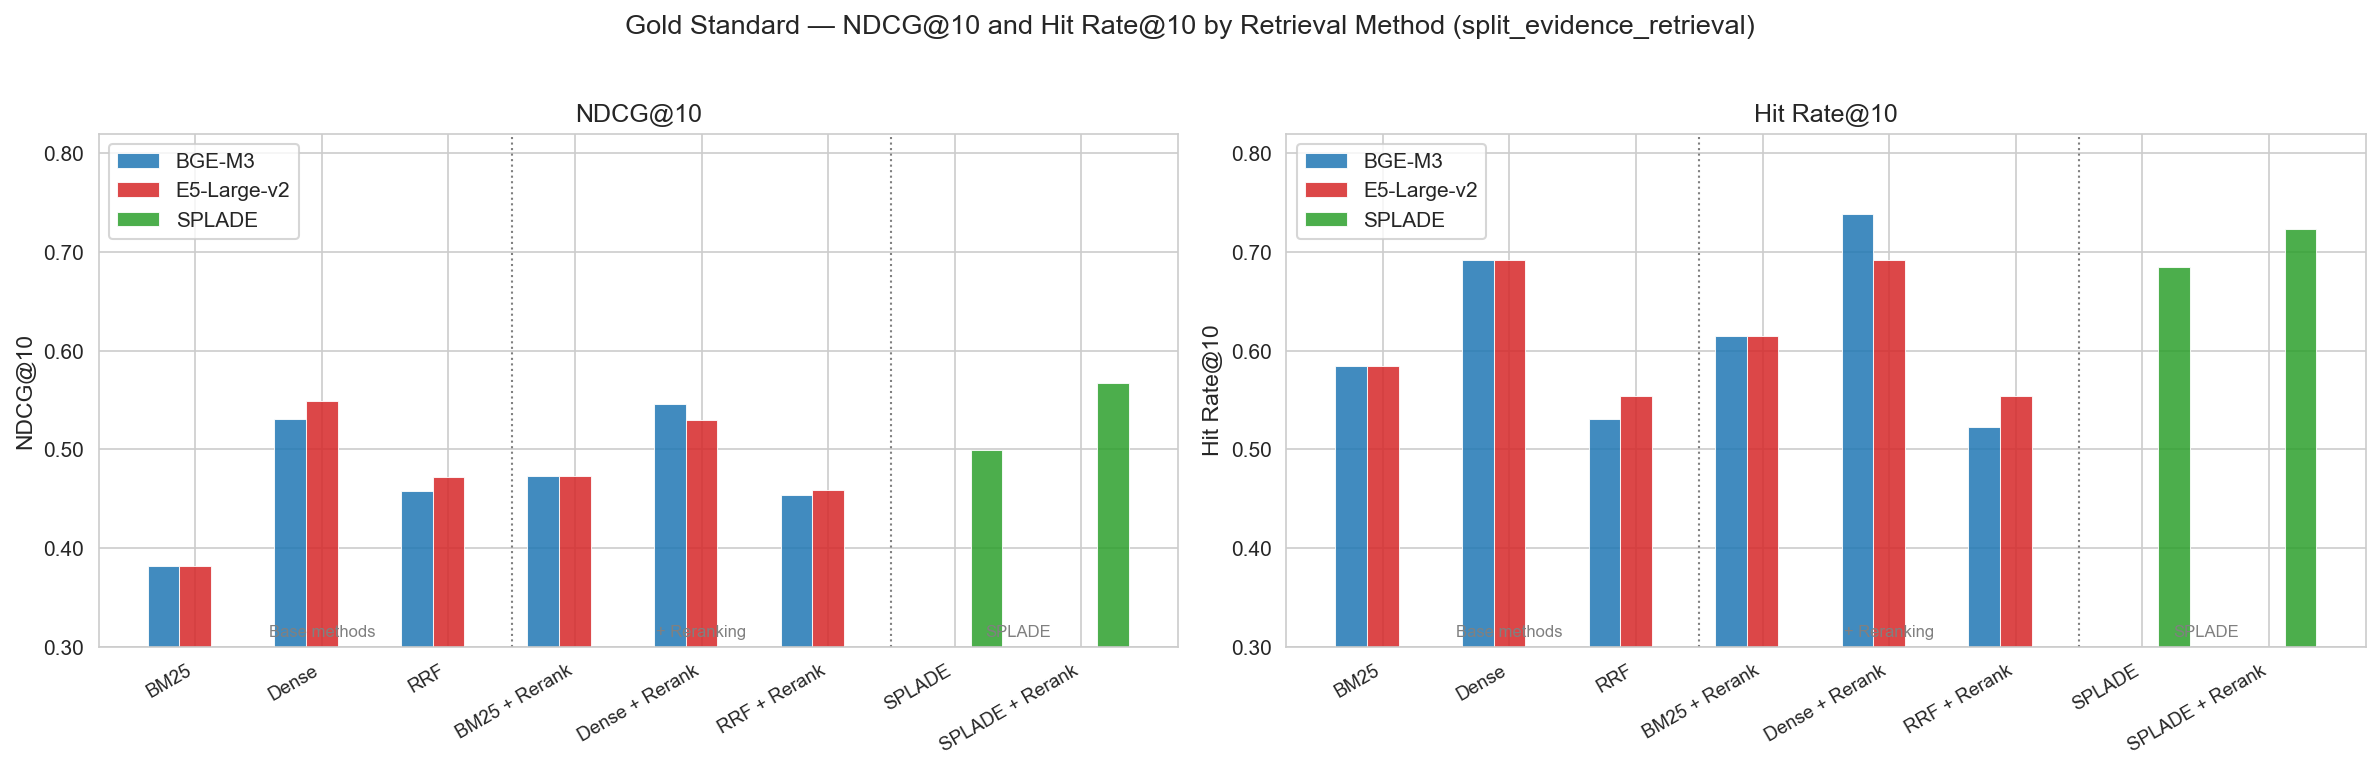

In [12]:
bar_df = gold_k10_all[['model_key', 'method', 'ndcg', 'mrr', 'hit_rate']].copy()
bar_df['method_label'] = bar_df['method'].map(label_method)
bar_df['model_label']  = bar_df['model_key'].map(label_model)

# Order methods and keep all models
bar_df['method_ord'] = bar_df['method'].map({m: i for i, m in enumerate(METHOD_ORDER)})
bar_df = bar_df.sort_values('method_ord')

# Figure: NDCG@10 and Hit Rate@10 grouped bar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

PLOT_MODELS = [('bge-m3', 'BGE-M3'), ('e5-large-v2', 'E5-Large-v2'), ('splade', 'SPLADE')]

for ax, (metric_col, metric_label) in zip(axes, [('ndcg', 'NDCG@10'), ('hit_rate', 'Hit Rate@10')]):
    x = np.arange(len(METHOD_ORDER))
    width = 0.25

    for i, (model_key, model_label) in enumerate(PLOT_MODELS):
        vals = []
        for method in METHOD_ORDER:
            row = bar_df[(bar_df['model_key'] == model_key) & (bar_df['method'] == method)]
            vals.append(row[metric_col].values[0] if not row.empty else np.nan)

        offset = (i - 1) * width
        ax.bar(x + offset, vals, width,
               label=model_label,
               color=MODEL_COLORS[model_key],
               alpha=0.85,
               edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_ORDER], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label)
    ax.set_ylim(0.3, 0.82)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend()

    # Divider between base and reranked methods
    ax.axvline(2.5, color='grey', linestyle=':', linewidth=1)
    # Divider between dense/hybrid reranked and SPLADE
    ax.axvline(5.5, color='grey', linestyle=':', linewidth=1)
    ax.text(1.0, ax.get_ylim()[0] + 0.01, 'Base methods', ha='center', fontsize=8, color='grey')
    ax.text(4.0, ax.get_ylim()[0] + 0.01, '+ Reranking', ha='center', fontsize=8, color='grey')
    ax.text(6.5, ax.get_ylim()[0] + 0.01, 'SPLADE', ha='center', fontsize=8, color='grey')

plt.suptitle('Gold Standard — NDCG@10 and Hit Rate@10 by Retrieval Method (split_evidence_retrieval)', fontsize=13, y=1.02)
plt.tight_layout()
savefig('fig_grouped_bar_gold.png')
plt.show()


## 10. Key Findings Summary

In [13]:
# Find best configuration per dataset
gold_best  = gold_k10_all.sort_values('ndcg', ascending=False).iloc[0]
mteb_best  = mteb_k10_all.sort_values('ndcg', ascending=False).iloc[0]

# Reranking delta
bm25_ndcg_gold = gold_k10_all[(gold_k10_all['method'] == 'bm25') & (gold_k10_all['model_key'] == 'bge-m3')]['ndcg'].values[0]
rrf_rr_e5_ndcg = gold_k10_all[(gold_k10_all['method'] == 'rrf_rerank') & (gold_k10_all['model_key'] == 'e5-large-v2')]['ndcg'].values[0]

print('=' * 72)
print('RETRIEVAL EVALUATION — KEY FINDINGS (k=10)')
print('=' * 72)
print()
print('GOLD STANDARD (130 queries, document level)')
print('-' * 45)
print(f'  Best configuration : {MODEL_LABELS[gold_best["model_key"]]} + {METHOD_LABELS[gold_best["method"]]}')
print(f'  NDCG@10            : {gold_best["ndcg"]:.4f}')
print(f'  MRR@10             : {gold_best["mrr"]:.4f}')
print(f'  Hit Rate@10        : {gold_best["hit_rate"]:.4f}')
print()
print(f'  Improvement over BM25 baseline (NDCG@10) :')
print(f'    BM25                 : {bm25_ndcg_gold:.4f}')
print(f'    Best (E5 RRF+Rerank) : {rrf_rr_e5_ndcg:.4f}')
print(f'    Δ                    : +{rrf_rr_e5_ndcg - bm25_ndcg_gold:.4f} (+{(rrf_rr_e5_ndcg/bm25_ndcg_gold - 1)*100:.1f}%)')
print()
print('MTEB MuPLeR (200 queries, chunk level)')
print('-' * 45)
print(f'  Best configuration : {MODEL_LABELS[mteb_best["model_key"]]} + {METHOD_LABELS[mteb_best["method"]]}')
print(f'  NDCG@10            : {mteb_best["ndcg"]:.4f}')
print(f'  MRR@10             : {mteb_best["mrr"]:.4f}')
print(f'  Hit Rate@10        : {mteb_best["hit_rate"]:.4f}')
print()
print('CROSS-CUTTING OBSERVATIONS')
print('-' * 45)

# Avg reranking gain
ndcg_gains = []
for base, reranked in PAIRS:
    for model in ['bge-m3', 'e5-large-v2']:
        b = gold_k10_all[(gold_k10_all['method'] == base) & (gold_k10_all['model_key'] == model)]['ndcg']
        r = gold_k10_all[(gold_k10_all['method'] == reranked) & (gold_k10_all['model_key'] == model)]['ndcg']
        if not b.empty and not r.empty:
            ndcg_gains.append(r.values[0] - b.values[0])

print(f'  Avg NDCG@10 gain from reranking   : +{np.mean(ndcg_gains):.4f}')
print(f'  Max NDCG@10 gain from reranking   : +{np.max(ndcg_gains):.4f} (BM25 → BM25+Rerank)')

# Model comparison overall
bge_mean = gold_k10_all[gold_k10_all['model_key'] == 'bge-m3']['ndcg'].mean()
e5_mean  = gold_k10_all[gold_k10_all['model_key'] == 'e5-large-v2']['ndcg'].mean()
print(f'  BGE-M3 mean NDCG@10 (gold)        : {bge_mean:.4f}')
print(f'  E5-Large-v2 mean NDCG@10 (gold)   : {e5_mean:.4f}')
means = {'BGE-M3': bge_mean, 'E5-Large-v2': e5_mean}
winner = max(means, key=means.get)
print(f'  Overall winner on gold standard   : {winner}')
print()
print('=' * 72)

RETRIEVAL EVALUATION — KEY FINDINGS (k=10)

GOLD STANDARD (130 queries, document level)
---------------------------------------------
  Best configuration : SPLADE + SPLADE + Rerank
  NDCG@10            : 0.5674
  MRR@10             : 0.5178
  Hit Rate@10        : 0.7231

  Improvement over BM25 baseline (NDCG@10) :
    BM25                 : 0.3822
    Best (E5 RRF+Rerank) : 0.4591
    Δ                    : +0.0769 (+20.1%)

MTEB MuPLeR (200 queries, chunk level)
---------------------------------------------
  Best configuration : E5-Large-v2 + Dense + Rerank
  NDCG@10            : 0.9603
  MRR@10             : 0.9505
  Hit Rate@10        : 0.9900

CROSS-CUTTING OBSERVATIONS
---------------------------------------------
  Avg NDCG@10 gain from reranking   : +0.0265
  Max NDCG@10 gain from reranking   : +0.0906 (BM25 → BM25+Rerank)
  BGE-M3 mean NDCG@10 (gold)        : 0.4739
  E5-Large-v2 mean NDCG@10 (gold)   : 0.4777
  Overall winner on gold standard   : E5-Large-v2



---
## 11. Export Figure Paths

All figures saved to `outputs/eval_prompt_final/figures_thesis/`.

In [14]:
print(f'Figures saved in: {FIG_DIR}')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')

Figures saved in: C:\Users\sara-\Documents\Stockholm\University of Stockholm\Master Thesis\Repository\RAG-for-Aligning-Greener-Electronics-Recommendations\outputs\eval_mteb_k_split\figures_thesis
  fig_grouped_bar_gold.png
  fig_h2h_gap.png
  fig_heatmap_gold_k10.png
  fig_metric_trends_by_k.png
  fig_mteb_trends.png
  fig_reranking_delta.png
